
INFORMACIÓN GENERAL DEL DATASET

Descripción breve del dataset:
.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Rad

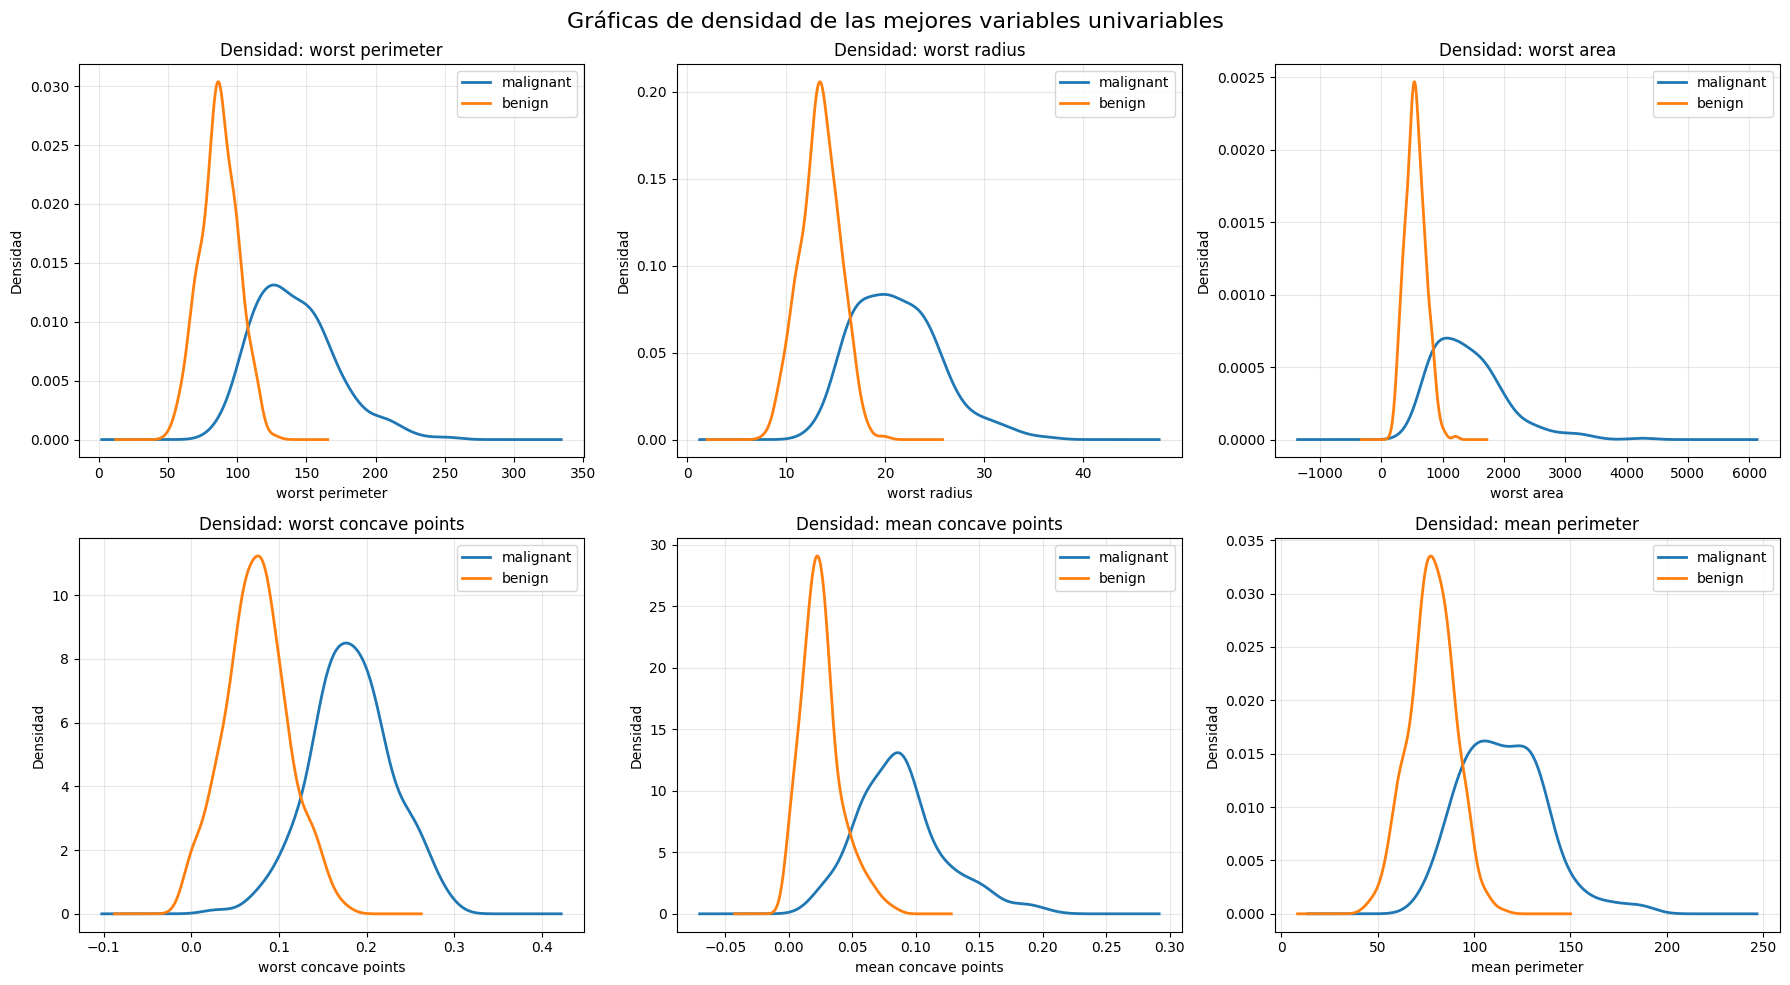

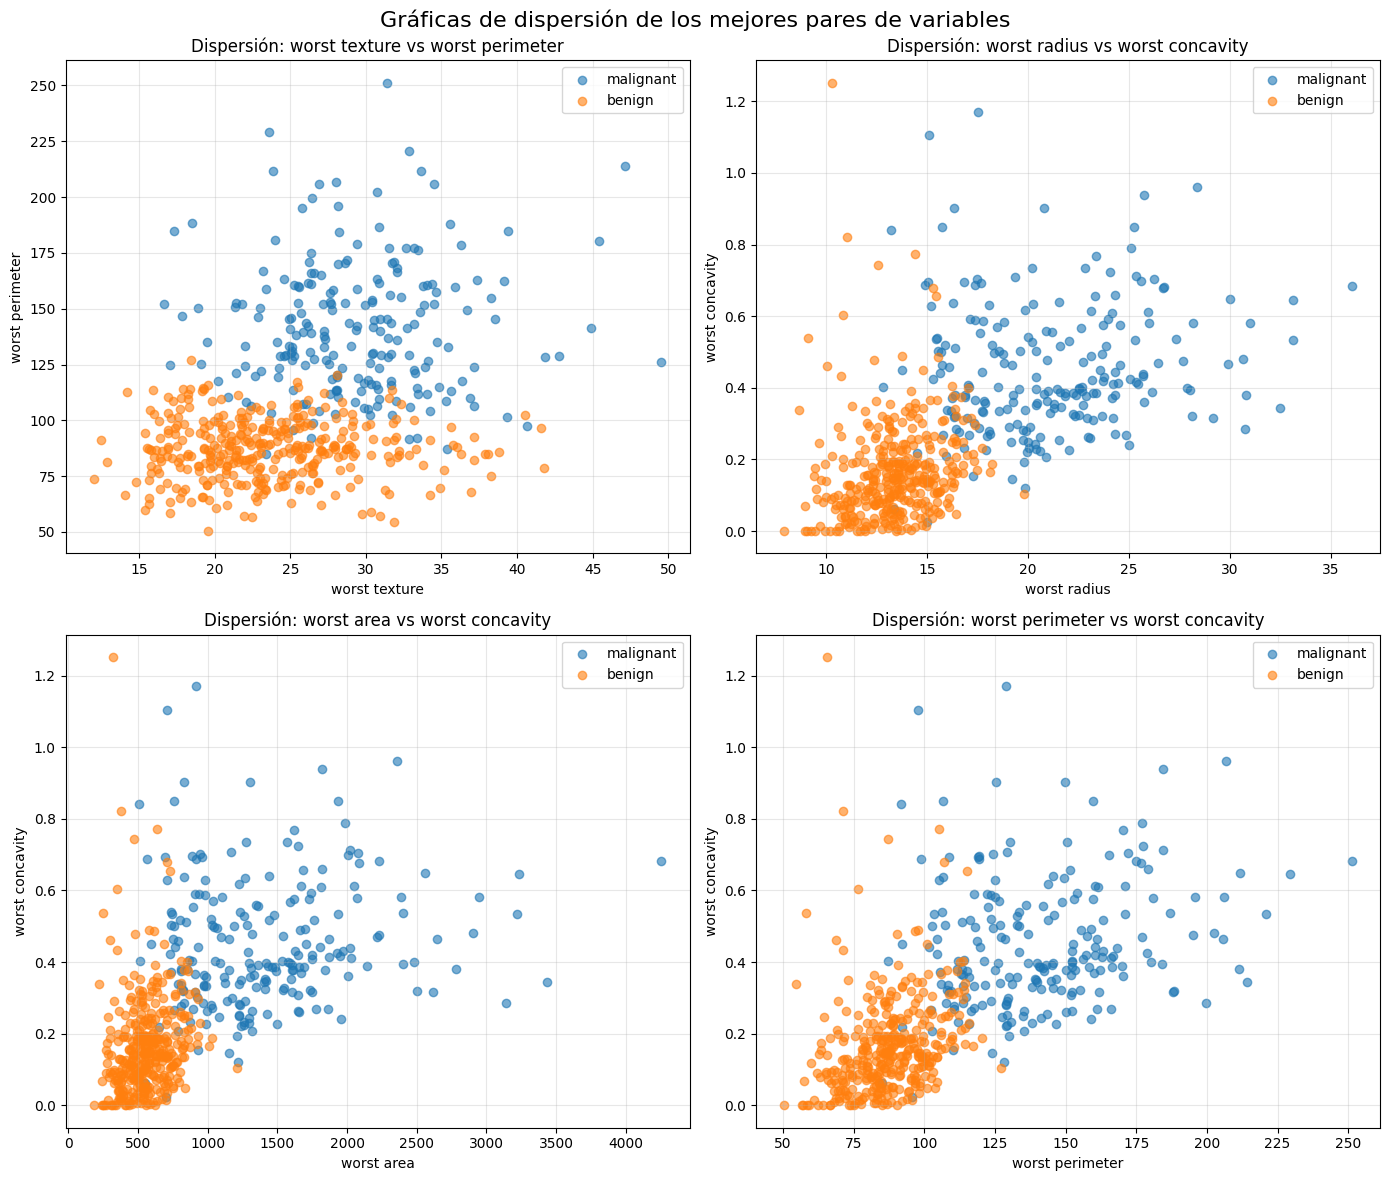


RESUMEN FINAL

Mejor variable univariable:
feature          worst perimeter
mean_auc                0.979729
std_auc                 0.016378
mean_accuracy           0.913911
std_accuracy            0.015959

Mejor par bivariable:
feature_1          worst texture
feature_2        worst perimeter
mean_auc                0.987539
std_auc                 0.010224
mean_accuracy           0.945552
std_accuracy            0.021717

Conclusión rápida:
Se evaluó la capacidad de clasificación usando regresión logística con validación cruzada. Primero se analizaron variables individuales y luego combinaciones de dos variables. Las mejores variables y pares se seleccionaron con base en el AUC promedio. Finalmente, se visualizaron con gráficas de densidad y de dispersión para observar la separación entre clases.


In [1]:
# ============================================
# PIPELINE DE ANÁLISIS - BREAST CANCER DATASET
# ============================================

import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

warnings.filterwarnings("ignore")


# =========================================================
# 1. IMPORTAR DATASET
# =========================================================
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Crear un DataFrame completo
df = X.copy()
df["target"] = y
df["class_name"] = df["target"].map({0: data.target_names[0], 1: data.target_names[1]})


# =========================================================
# 2. REVISAR CARACTERÍSTICAS GENERALES
# =========================================================
print("\n" + "=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

print("\nDescripción breve del dataset:")
print(data.DESCR[:1500], "...")  # solo una parte para no saturar la salida

print("\nNombres de las características:")
for i, feature in enumerate(data.feature_names, start=1):
    print(f"{i:2d}. {feature}")

print("\nTamaño del dataset:")
print(f"Filas (muestras): {X.shape[0]}")
print(f"Columnas (features): {X.shape[1]}")

print("\nTipo de información:")
print(X.dtypes)

print("\nResumen tipo info():")

# info() imprime directamente, así que usamos un buffer
from io import StringIO
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

print("Clases:")
print(f"Etiquetas numéricas: {np.unique(y)}")
print(f"Nombres de clases: {data.target_names}")
print("\nConteo por clase:")
print(df["class_name"].value_counts())

print("\nHuecos / valores faltantes:")
print(df.isnull().sum())
print(f"\nTotal de valores faltantes en todo el dataset: {df.isnull().sum().sum()}")


# =========================================================
# 3. REVISAR CAPACIDAD DE CLASIFICACIÓN UNIVARIABLE
# =========================================================
print("\n" + "=" * 60)
print("CAPACIDAD DE CLASIFICACIÓN UNIVARIABLE")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=5000)

univ_results = []

for feature in X.columns:
    X_uni = X[[feature]]

    auc_scores = cross_val_score(
        model, X_uni, y, cv=cv, scoring="roc_auc"
    )
    acc_scores = cross_val_score(
        model, X_uni, y, cv=cv, scoring="accuracy"
    )

    univ_results.append({
        "feature": feature,
        "mean_auc": auc_scores.mean(),
        "std_auc": auc_scores.std(),
        "mean_accuracy": acc_scores.mean(),
        "std_accuracy": acc_scores.std()
    })

univ_df = pd.DataFrame(univ_results).sort_values(by="mean_auc", ascending=False)

print("\nTop 10 variables univariables con mejor AUC:")
print(univ_df.head(10).to_string(index=False))


# =========================================================
# 4. REVISAR CAPACIDAD DE CLASIFICACIÓN BIVARIABLE
# =========================================================
print("\n" + "=" * 60)
print("CAPACIDAD DE CLASIFICACIÓN BIVARIABLE")
print("=" * 60)

biv_results = []

feature_pairs = list(itertools.combinations(X.columns, 2))

for f1, f2 in feature_pairs:
    X_bi = X[[f1, f2]]

    auc_scores = cross_val_score(
        model, X_bi, y, cv=cv, scoring="roc_auc"
    )
    acc_scores = cross_val_score(
        model, X_bi, y, cv=cv, scoring="accuracy"
    )

    biv_results.append({
        "feature_1": f1,
        "feature_2": f2,
        "mean_auc": auc_scores.mean(),
        "std_auc": auc_scores.std(),
        "mean_accuracy": acc_scores.mean(),
        "std_accuracy": acc_scores.std()
    })

biv_df = pd.DataFrame(biv_results).sort_values(by="mean_auc", ascending=False)

print("\nTop 10 pares de variables con mejor AUC:")
print(biv_df.head(10).to_string(index=False))


# =========================================================
# 5. GRÁFICAS DE DENSIDAD
#    Usaremos las 6 mejores variables univariables
# =========================================================
top_uni_features = univ_df.head(6)["feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, top_uni_features):
    df[df["target"] == 0][feature].plot(kind="kde", ax=ax, label=data.target_names[0], linewidth=2)
    df[df["target"] == 1][feature].plot(kind="kde", ax=ax, label=data.target_names[1], linewidth=2)
    ax.set_title(f"Densidad: {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidad")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Gráficas de densidad de las mejores variables univariables", fontsize=16)
plt.tight_layout()
plt.show()


# =========================================================
# 6. GRÁFICAS DE DISPERSIÓN
#    Usaremos los 4 mejores pares bivariables
# =========================================================
top_bi_pairs = biv_df.head(4)[["feature_1", "feature_2"]].values.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (f1, f2) in zip(axes, top_bi_pairs):
    class_0 = df[df["target"] == 0]
    class_1 = df[df["target"] == 1]

    ax.scatter(class_0[f1], class_0[f2], alpha=0.6, label=data.target_names[0])
    ax.scatter(class_1[f1], class_1[f2], alpha=0.6, label=data.target_names[1])

    ax.set_title(f"Dispersión: {f1} vs {f2}")
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Gráficas de dispersión de los mejores pares de variables", fontsize=16)
plt.tight_layout()
plt.show()


# =========================================================
# 7. RESUMEN FINAL AUTOMÁTICO
# =========================================================
print("\n" + "=" * 60)
print("RESUMEN FINAL")
print("=" * 60)

print("\nMejor variable univariable:")
print(univ_df.iloc[0].to_string())

print("\nMejor par bivariable:")
print(biv_df.iloc[0].to_string())

print("\nConclusión rápida:")
print(
    "Se evaluó la capacidad de clasificación usando regresión logística con validación cruzada. "
    "Primero se analizaron variables individuales y luego combinaciones de dos variables. "
    "Las mejores variables y pares se seleccionaron con base en el AUC promedio. "
    "Finalmente, se visualizaron con gráficas de densidad y de dispersión para observar "
    "la separación entre clases."
)


INFORMACIÓN GENERAL DEL DATASET

Primeras 5 filas:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst pe

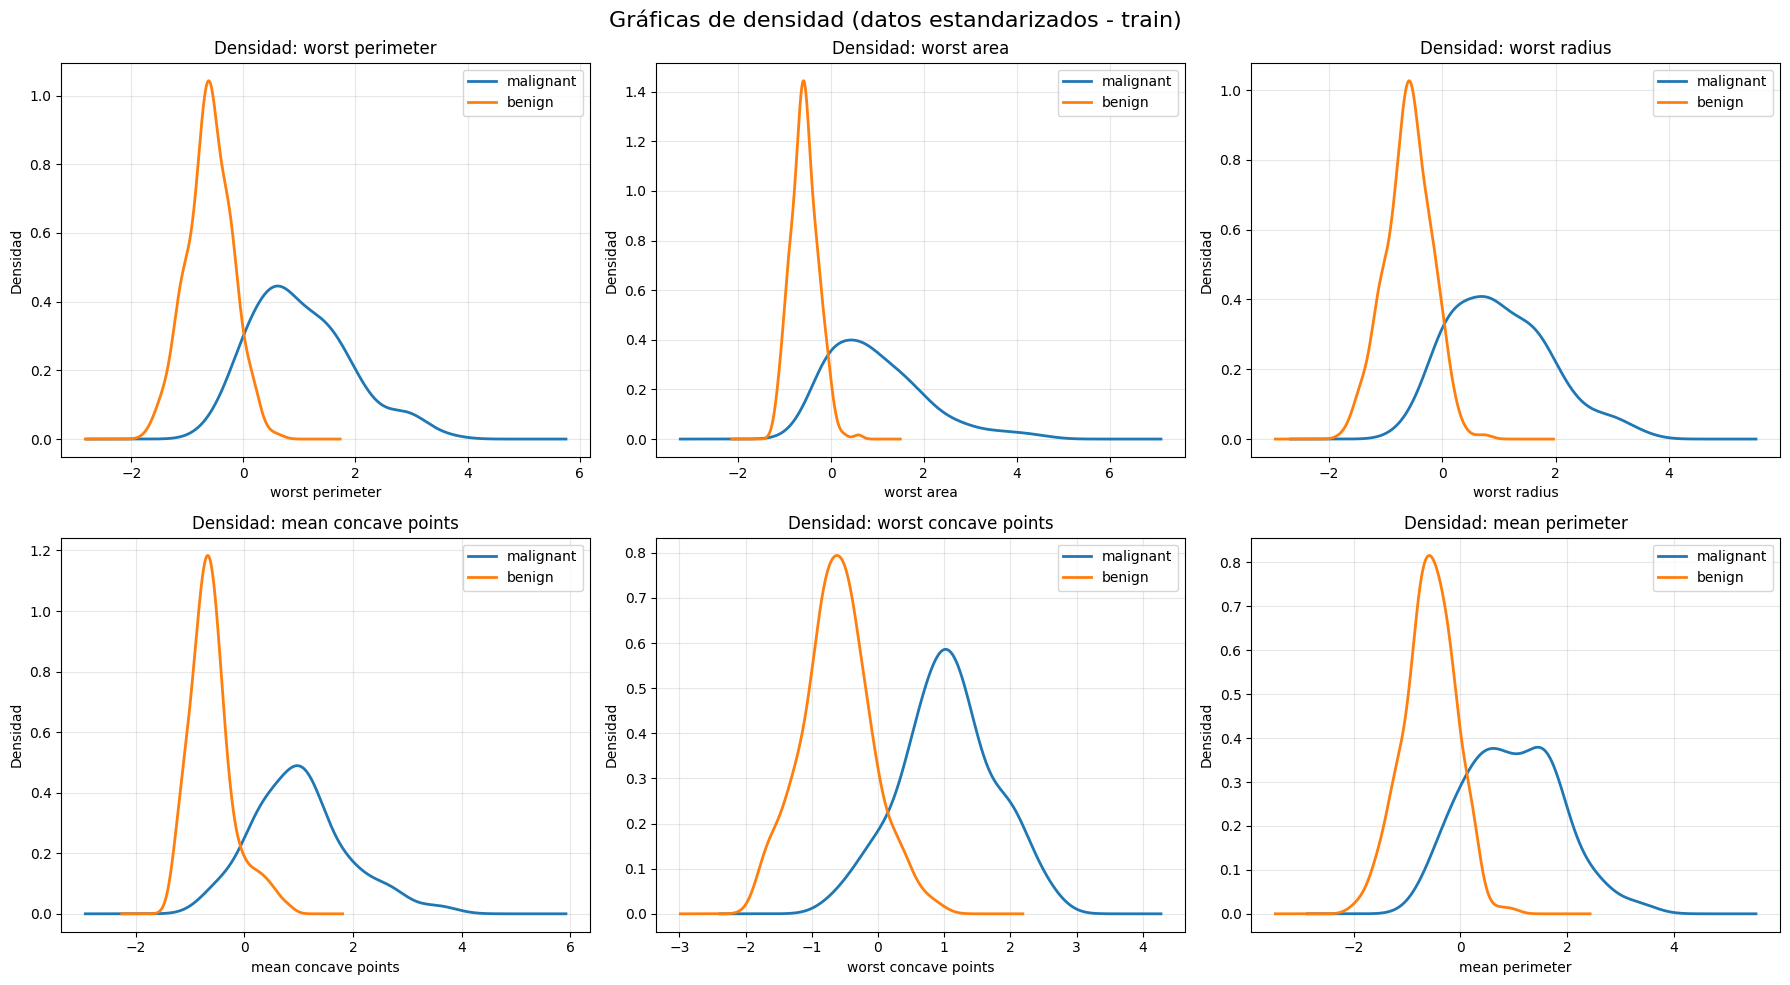

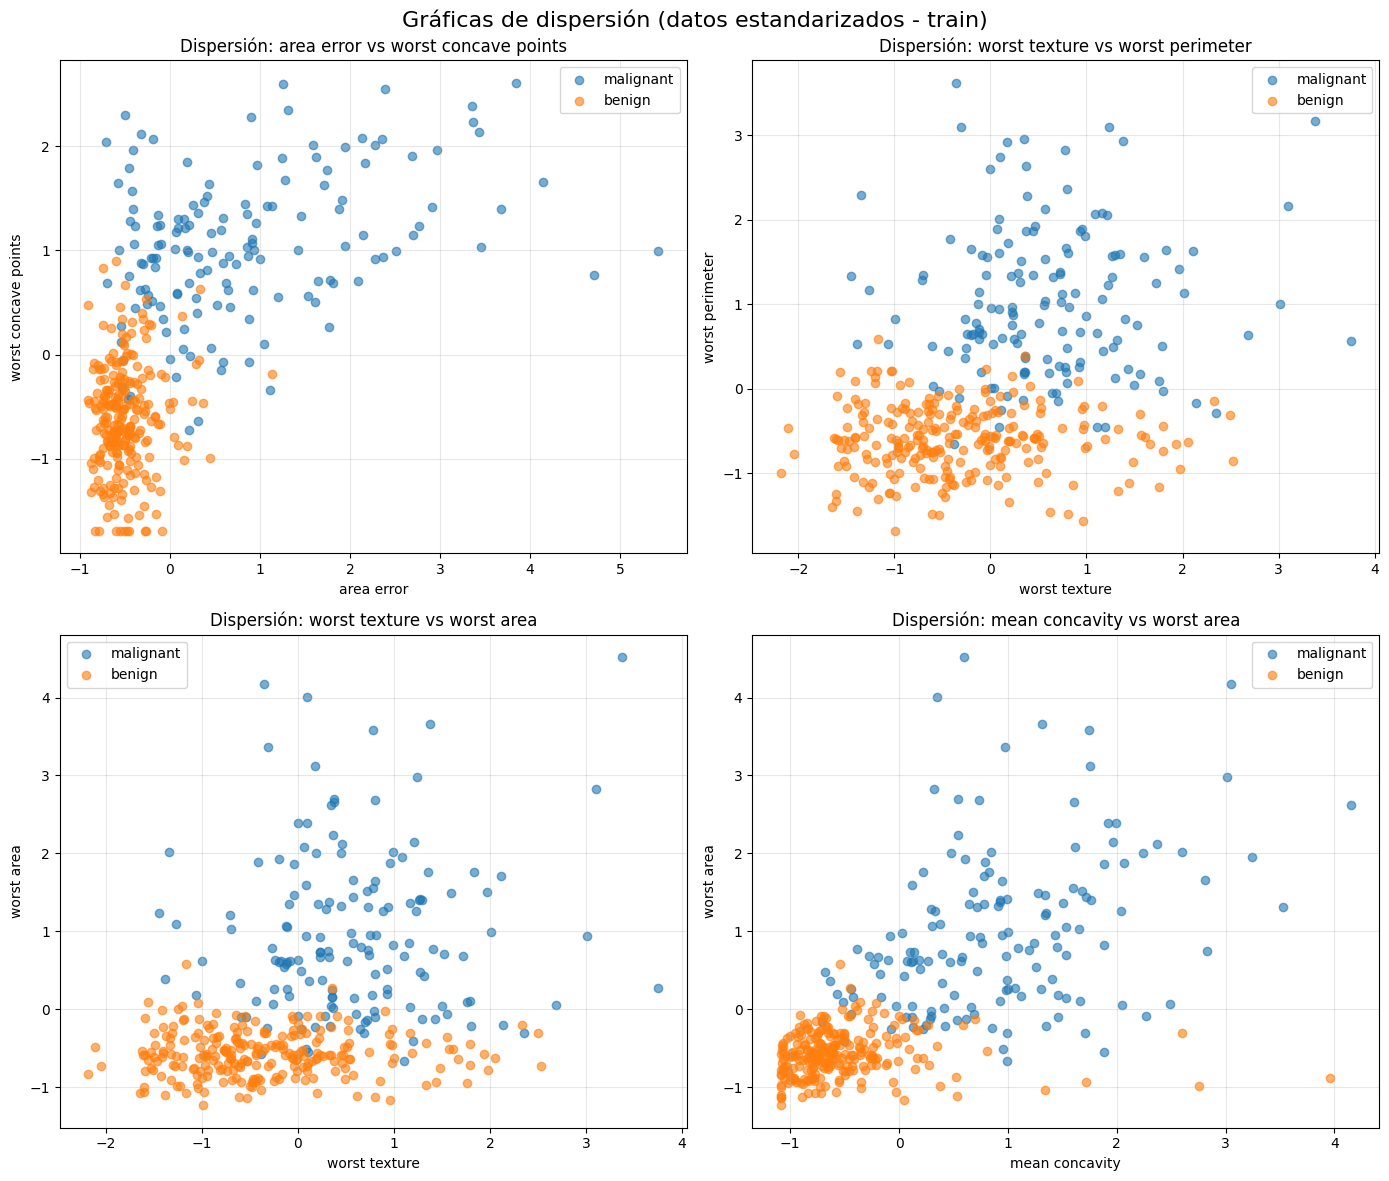


RESUMEN FINAL

Mejor variable univariable:
feature          worst perimeter
accuracy_test           0.906433
auc_test                0.974372

Mejor par bivariable:
feature_1                  area error
feature_2        worst concave points
accuracy_test                0.935673
auc_test                     0.989048


In [2]:
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from io import StringIO
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

warnings.filterwarnings("ignore")

# =========================================================
# 1. IMPORTAR DATASET
# =========================================================
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

df = X.copy()
df["target"] = y
df["class_name"] = df["target"].map({0: data.target_names[0], 1: data.target_names[1]})

# =========================================================
# 2. REVISAR CARACTERÍSTICAS DEL DATASET
# =========================================================
print("\n" + "=" * 70)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 70)

print("\nPrimeras 5 filas:")
print(df.head())

print("\nTamaño del dataset:")
print(f"Muestras: {X.shape[0]}")
print(f"Características: {X.shape[1]}")

print("\nTipo de información:")
print(X.dtypes)

print("\nResumen tipo info():")
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

print("Clases:")
print(f"Etiquetas numéricas: {np.unique(y)}")
print(f"Nombres de clases: {data.target_names}")
print("\nConteo por clase:")
print(df["class_name"].value_counts())

print("\nHuecos / valores faltantes por columna:")
print(df.isnull().sum())
print(f"\nTotal de valores faltantes: {df.isnull().sum().sum()}")

# =========================================================
# 3. SEPARAR EN TRAIN Y TEST
#    Train 70% - Test 30%
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("SEPARACIÓN TRAIN / TEST")
print("=" * 70)
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

print("\nDistribución de clases en train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución de clases en test:")
print(y_test.value_counts(normalize=True).sort_index())

# =========================================================
# 4. ESTANDARIZAR DATOS
#    Media 0
#    Desviación estándar 1
# =========================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # se ajusta SOLO con train
X_test_scaled = scaler.transform(X_test)         # test se transforma con el mismo scaler

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\n" + "=" * 70)
print("VERIFICACIÓN DE ESTANDARIZACIÓN EN TRAIN")
print("=" * 70)

print("\nMedia de las primeras 5 variables en train escalado:")
print(X_train_scaled.mean().head().round(6))

print("\nDesviación estándar de las primeras 5 variables en train escalado:")
print(X_train_scaled.std(ddof=0).head().round(6))  # ddof=0 para coincidir con StandardScaler

print("\nPromedio absoluto de las medias en train:")
print(np.abs(X_train_scaled.mean()).mean().round(8))

print("Promedio de las desviaciones estándar en train:")
print(X_train_scaled.std(ddof=0).mean().round(8))

# =========================================================
# 5. CAPACIDAD DE CLASIFICACIÓN UNIVARIABLE
#    Entrena con train y evalúa en test
# =========================================================
print("\n" + "=" * 70)
print("CAPACIDAD DE CLASIFICACIÓN UNIVARIABLE")
print("=" * 70)

univ_results = []
model = LogisticRegression(max_iter=5000)

for feature in X.columns:
    Xtr = X_train_scaled[[feature]]
    Xts = X_test_scaled[[feature]]

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xts)
    y_prob = model.predict_proba(Xts)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    univ_results.append({
        "feature": feature,
        "accuracy_test": acc,
        "auc_test": auc
    })

univ_df = pd.DataFrame(univ_results).sort_values(by="auc_test", ascending=False)

print("\nTop 10 variables univariables:")
print(univ_df.head(10).to_string(index=False))

# =========================================================
# 6. CAPACIDAD DE CLASIFICACIÓN BIVARIABLE
#    Entrena con train y evalúa en test
# =========================================================
print("\n" + "=" * 70)
print("CAPACIDAD DE CLASIFICACIÓN BIVARIABLE")
print("=" * 70)

biv_results = []

for f1, f2 in itertools.combinations(X.columns, 2):
    Xtr = X_train_scaled[[f1, f2]]
    Xts = X_test_scaled[[f1, f2]]

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xts)
    y_prob = model.predict_proba(Xts)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    biv_results.append({
        "feature_1": f1,
        "feature_2": f2,
        "accuracy_test": acc,
        "auc_test": auc
    })

biv_df = pd.DataFrame(biv_results).sort_values(by="auc_test", ascending=False)

print("\nTop 10 pares bivariable:")
print(biv_df.head(10).to_string(index=False))

# =========================================================
# 7. GRÁFICAS DE DENSIDAD
#    Se usan las mejores 6 variables univariables en train
# =========================================================
top_uni_features = univ_df.head(6)["feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, top_uni_features):
    X_train_scaled.loc[y_train[y_train == 0].index, feature].plot(
        kind="kde", ax=ax, label=data.target_names[0], linewidth=2
    )
    X_train_scaled.loc[y_train[y_train == 1].index, feature].plot(
        kind="kde", ax=ax, label=data.target_names[1], linewidth=2
    )

    ax.set_title(f"Densidad: {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidad")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Gráficas de densidad (datos estandarizados - train)", fontsize=16)
plt.tight_layout()
plt.show()

# =========================================================
# 8. GRÁFICAS DE DISPERSIÓN
#    Se usan los mejores 4 pares bivariables en train
# =========================================================
top_bi_pairs = biv_df.head(4)[["feature_1", "feature_2"]].values.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (f1, f2) in zip(axes, top_bi_pairs):
    idx0 = y_train[y_train == 0].index
    idx1 = y_train[y_train == 1].index

    ax.scatter(
        X_train_scaled.loc[idx0, f1],
        X_train_scaled.loc[idx0, f2],
        alpha=0.6,
        label=data.target_names[0]
    )
    ax.scatter(
        X_train_scaled.loc[idx1, f1],
        X_train_scaled.loc[idx1, f2],
        alpha=0.6,
        label=data.target_names[1]
    )

    ax.set_title(f"Dispersión: {f1} vs {f2}")
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Gráficas de dispersión (datos estandarizados - train)", fontsize=16)
plt.tight_layout()
plt.show()

# =========================================================
# 9. RESUMEN FINAL
# =========================================================
print("\n" + "=" * 70)
print("RESUMEN FINAL")
print("=" * 70)

print("\nMejor variable univariable:")
print(univ_df.iloc[0].to_string())

print("\nMejor par bivariable:")
print(biv_df.iloc[0].to_string())

In [3]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# =========================================================
# 10. REGRESIÓN LOGÍSTICA OPTIMIZANDO F1 SCORE
# =========================================================
print("\n" + "=" * 70)
print("REGRESIÓN LOGÍSTICA OPTIMIZANDO F1 SCORE")
print("=" * 70)

# Modelo base
log_reg = LogisticRegression(max_iter=10000)

# Espacio de búsqueda de hiperparámetros
param_grid = [
    {
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear"],
        "class_weight": [None, "balanced"]
    },
    {
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["lbfgs"],
        "class_weight": [None, "balanced"]
    }
]

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Búsqueda de mejores hiperparámetros optimizando F1
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento con train escalado
grid_search.fit(X_train_scaled, y_train)

# Mejor modelo encontrado
best_model = grid_search.best_estimator_

print("\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)

print(f"\nMejor F1 promedio en validación cruzada: {grid_search.best_score_:.4f}")

# =========================================================
# 11. EVALUACIÓN EN TEST
# =========================================================
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n" + "=" * 70)
print("MÉTRICAS EN TEST")
print("=" * 70)
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


REGRESIÓN LOGÍSTICA OPTIMIZANDO F1 SCORE
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores hiperparámetros encontrados:
{'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}

Mejor F1 promedio en validación cruzada: 0.9883

MÉTRICAS EN TEST
Accuracy : 0.9825
F1 Score : 0.9860
AUC      : 0.9966

Matriz de confusión:
[[ 62   2]
 [  1 106]]

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        64
      benign       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171




PCA

Shape original train: (398, 30)
Shape PCA train     : (398, 10)
Varianza explicada acumulada: 0.9562

Varianza explicada por componente:
PC1: 0.4516
PC2: 0.1963
PC3: 0.0890
PC4: 0.0660
PC5: 0.0554
PC6: 0.0400
PC7: 0.0207
PC8: 0.0151
PC9: 0.0117
PC10: 0.0104

HEATMAPS DE LOS DATASETS COMPLETOS


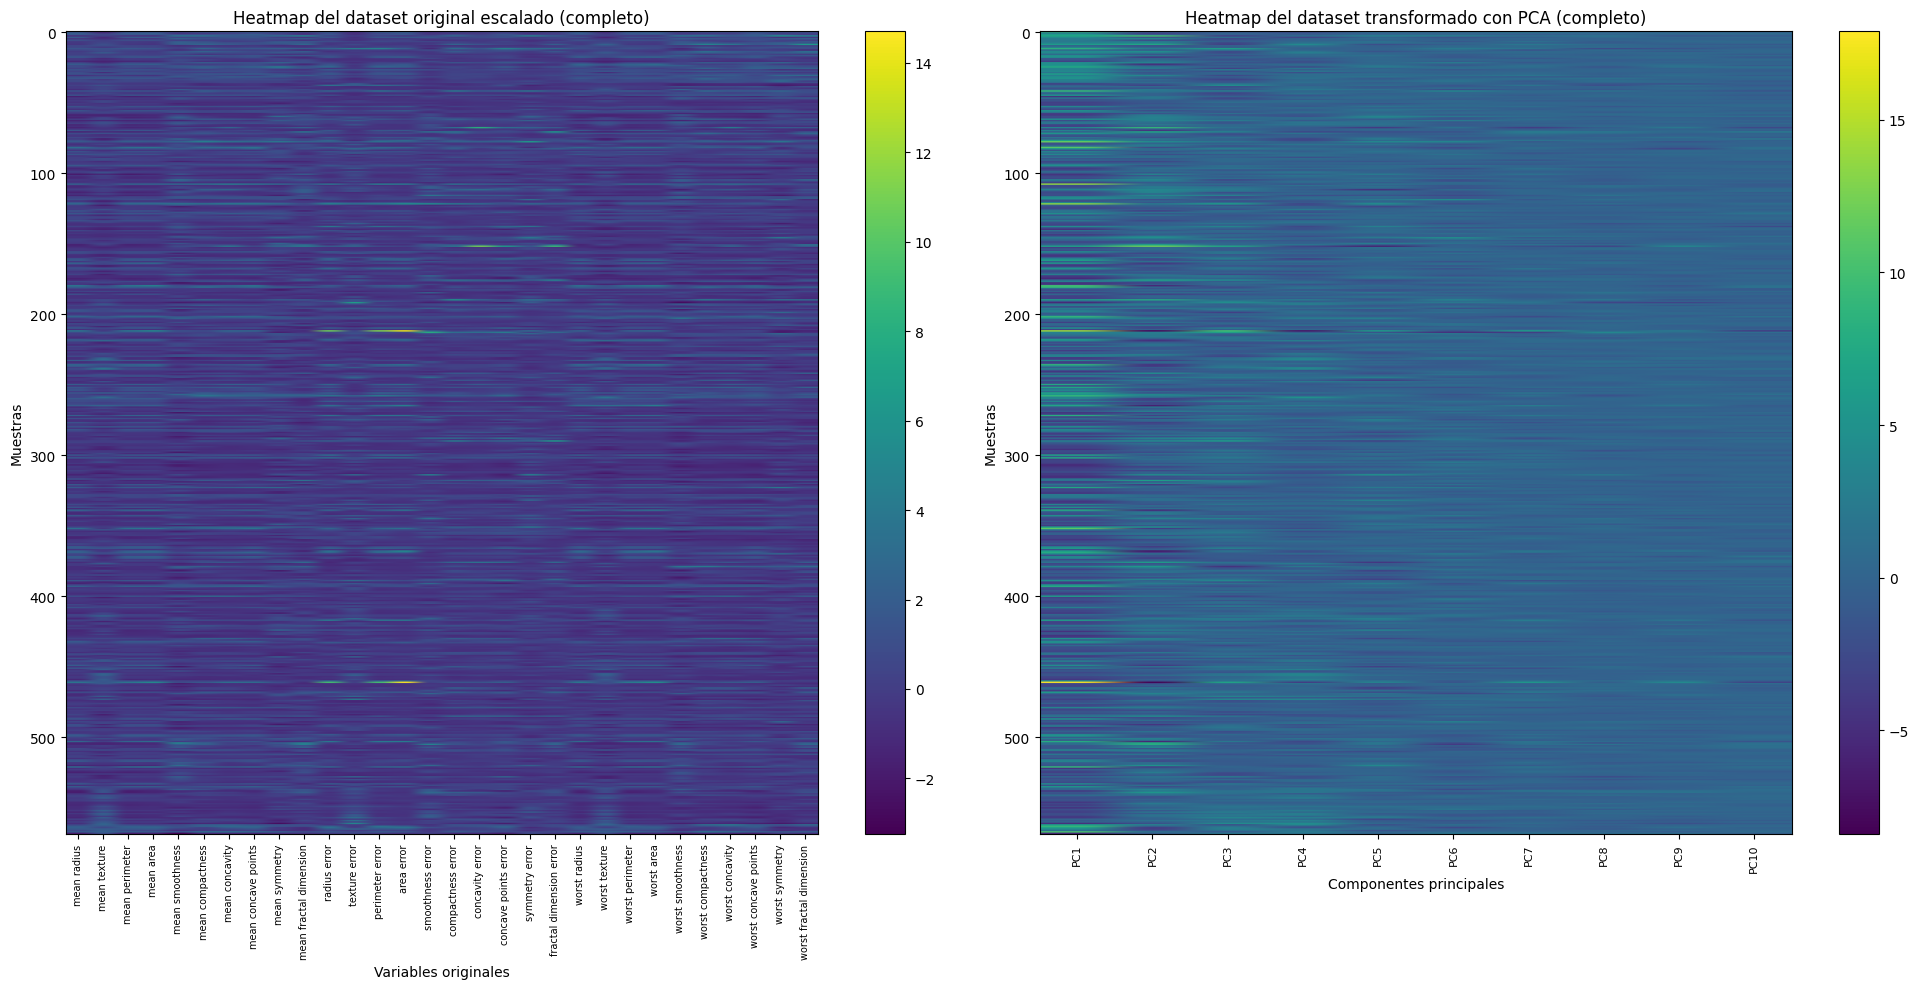


CORRELACIONES ENTRE VARIABLES

Resumen correlaciones dataset original:
                         mean radius  mean texture  mean perimeter  mean area  \
mean radius                    1.000         0.333           0.998      0.991   
mean texture                   0.333         1.000           0.335      0.333   
mean perimeter                 0.998         0.335           1.000      0.989   
mean area                      0.991         0.333           0.989      1.000   
mean smoothness                0.152        -0.051           0.190      0.166   
mean compactness               0.514         0.211           0.565      0.515   
mean concavity                 0.655         0.278           0.696      0.665   
mean concave points            0.819         0.272           0.848      0.825   
mean symmetry                  0.134         0.033           0.171      0.144   
mean fractal dimension        -0.309        -0.097          -0.257     -0.275   
radius error                   0.707 

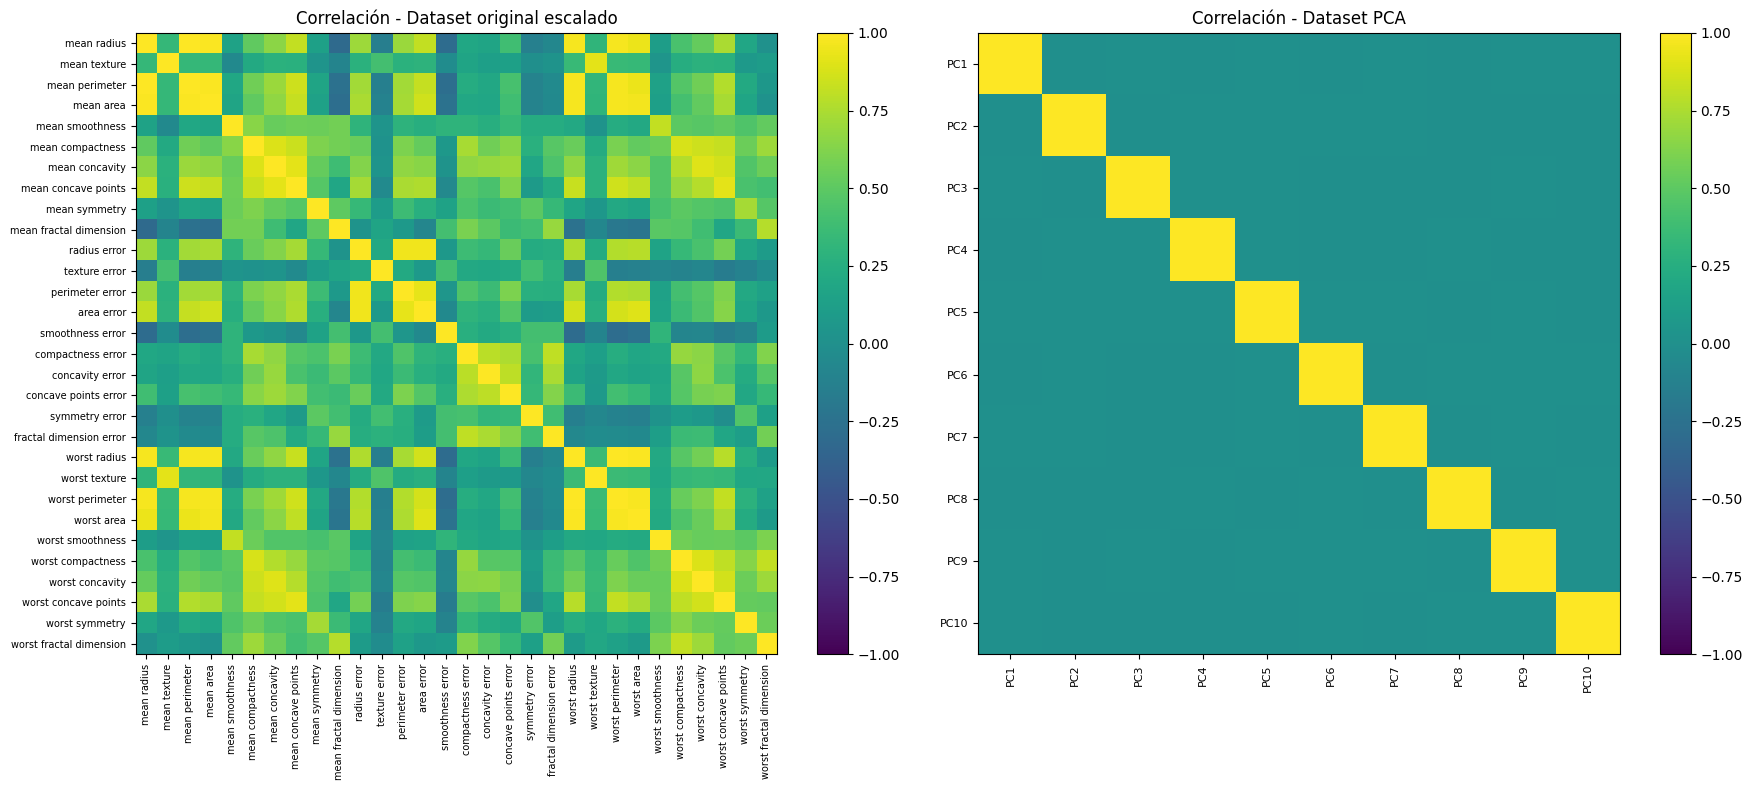


CLASIFICACIÓN CON DATASET PCA
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores hiperparámetros con PCA:
{'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor F1 promedio en validación cruzada: 0.9883

MÉTRICAS EN TEST - DATASET PCA
Accuracy : 0.9766
F1 Score : 0.9815
AUC      : 0.9965

Matriz de confusión - PCA:
[[ 61   3]
 [  1 106]]

Reporte de clasificación - PCA:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.97        64
      benign       0.97      0.99      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171


COMPARACIÓN FINAL
 Dataset  Accuracy  F1 Score      AUC
Original  0.982456  0.986047 0.996641
     PCA  0.976608  0.981481 0.996495


In [6]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# =========================================================
# 12. PCA
#    Se conserva el 95% de la varianza
# =========================================================
print("\n" + "=" * 70)
print("PCA")
print("=" * 70)

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nShape original train: {X_train_scaled.shape}")
print(f"Shape PCA train     : {X_train_pca.shape}")
print(f"Varianza explicada acumulada: {pca.explained_variance_ratio_.sum():.4f}")

# Nombres de componentes principales
pca_columns = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_columns, index=X_train_scaled.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_columns, index=X_test_scaled.index)

print("\nVarianza explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.4f}")

    # =========================================================
# DATASET COMPLETO ESCALADO Y TRANSFORMADO CON PCA
#    Para visualización de TODO el dataset
# =========================================================
X_all_scaled = pd.DataFrame(
    scaler.transform(X),   # usa el scaler ajustado con train
    columns=X.columns,
    index=X.index
)

X_all_pca = pd.DataFrame(
    pca.transform(X_all_scaled),
    columns=pca_columns,
    index=X.index
)

# =========================================================
# 13. HEATMAPS DE LOS DATASETS COMPLETOS
#    NO son correlaciones, solo visualización de datos
# =========================================================
print("\n" + "=" * 70)
print("HEATMAPS DE LOS DATASETS COMPLETOS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Heatmap del dataset original escalado completo
im1 = axes[0].imshow(X_all_scaled.values, aspect='auto')
axes[0].set_title("Heatmap del dataset original escalado (completo)")
axes[0].set_xlabel("Variables originales")
axes[0].set_ylabel("Muestras")

axes[0].set_xticks(range(len(X_all_scaled.columns)))
axes[0].set_xticklabels(X_all_scaled.columns, rotation=90, fontsize=7)

fig.colorbar(im1, ax=axes[0])

# Heatmap del dataset PCA completo
im2 = axes[1].imshow(X_all_pca.values, aspect='auto')
axes[1].set_title("Heatmap del dataset transformado con PCA (completo)")
axes[1].set_xlabel("Componentes principales")
axes[1].set_ylabel("Muestras")

axes[1].set_xticks(range(len(X_all_pca.columns)))
axes[1].set_xticklabels(X_all_pca.columns, rotation=90, fontsize=8)

fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

# =========================================================
# 14. CORRELACIONES ENTRE VARIABLES DE CADA DATASET
# =========================================================
print("\n" + "=" * 70)
print("CORRELACIONES ENTRE VARIABLES")
print("=" * 70)

corr_original = X_train_scaled.corr()
corr_pca = X_train_pca_df.corr()

print("\nResumen correlaciones dataset original:")
print(corr_original.round(3))

print("\nResumen correlaciones dataset PCA:")
print(corr_pca.round(3))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

im3 = axes[0].imshow(corr_original, aspect='auto', vmin=-1, vmax=1)
axes[0].set_title("Correlación - Dataset original escalado")
axes[0].set_xticks(range(len(corr_original.columns)))
axes[0].set_xticklabels(corr_original.columns, rotation=90, fontsize=7)
axes[0].set_yticks(range(len(corr_original.index)))
axes[0].set_yticklabels(corr_original.index, fontsize=7)
fig.colorbar(im3, ax=axes[0])

im4 = axes[1].imshow(corr_pca, aspect='auto', vmin=-1, vmax=1)
axes[1].set_title("Correlación - Dataset PCA")
axes[1].set_xticks(range(len(corr_pca.columns)))
axes[1].set_xticklabels(corr_pca.columns, rotation=90, fontsize=8)
axes[1].set_yticks(range(len(corr_pca.index)))
axes[1].set_yticklabels(corr_pca.index, fontsize=8)
fig.colorbar(im4, ax=axes[1])

plt.tight_layout()
plt.show()

# =========================================================
# 15. CLASIFICACIÓN CON EL NUEVO DATASET (PCA)
#    Optimización con F1 score
# =========================================================
print("\n" + "=" * 70)
print("CLASIFICACIÓN CON DATASET PCA")
print("=" * 70)

log_reg_pca = LogisticRegression(max_iter=10000)

param_grid_pca = [
    {
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear"],
        "class_weight": [None, "balanced"]
    },
    {
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["lbfgs"],
        "class_weight": [None, "balanced"]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_pca = GridSearchCV(
    estimator=log_reg_pca,
    param_grid=param_grid_pca,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search_pca.fit(X_train_pca_df, y_train)

best_model_pca = grid_search_pca.best_estimator_

print("\nMejores hiperparámetros con PCA:")
print(grid_search_pca.best_params_)
print(f"Mejor F1 promedio en validación cruzada: {grid_search_pca.best_score_:.4f}")

# Evaluación en test
y_pred_pca = best_model_pca.predict(X_test_pca_df)
y_prob_pca = best_model_pca.predict_proba(X_test_pca_df)[:, 1]

acc_pca = accuracy_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca)
auc_pca = roc_auc_score(y_test, y_prob_pca)

print("\n" + "=" * 70)
print("MÉTRICAS EN TEST - DATASET PCA")
print("=" * 70)
print(f"Accuracy : {acc_pca:.4f}")
print(f"F1 Score : {f1_pca:.4f}")
print(f"AUC      : {auc_pca:.4f}")

print("\nMatriz de confusión - PCA:")
print(confusion_matrix(y_test, y_pred_pca))

print("\nReporte de clasificación - PCA:")
print(classification_report(y_test, y_pred_pca, target_names=data.target_names))

# =========================================================
# 16. COMPARACIÓN FINAL: ORIGINAL VS PCA
# =========================================================
print("\n" + "=" * 70)
print("COMPARACIÓN FINAL")
print("=" * 70)

comparison_df = pd.DataFrame({
    "Dataset": ["Original", "PCA"],
    "Accuracy": [acc, acc_pca],
    "F1 Score": [f1, f1_pca],
    "AUC": [auc, auc_pca]
})

print(comparison_df.to_string(index=False))


PCA COMPLETO - ANÁLISIS DE VARIANZA

Número máximo de componentes posibles: 30

Componente estimado como codo: 4
Varianza explicada en el codo: 0.0660
Varianza acumulada hasta el codo: 0.8028


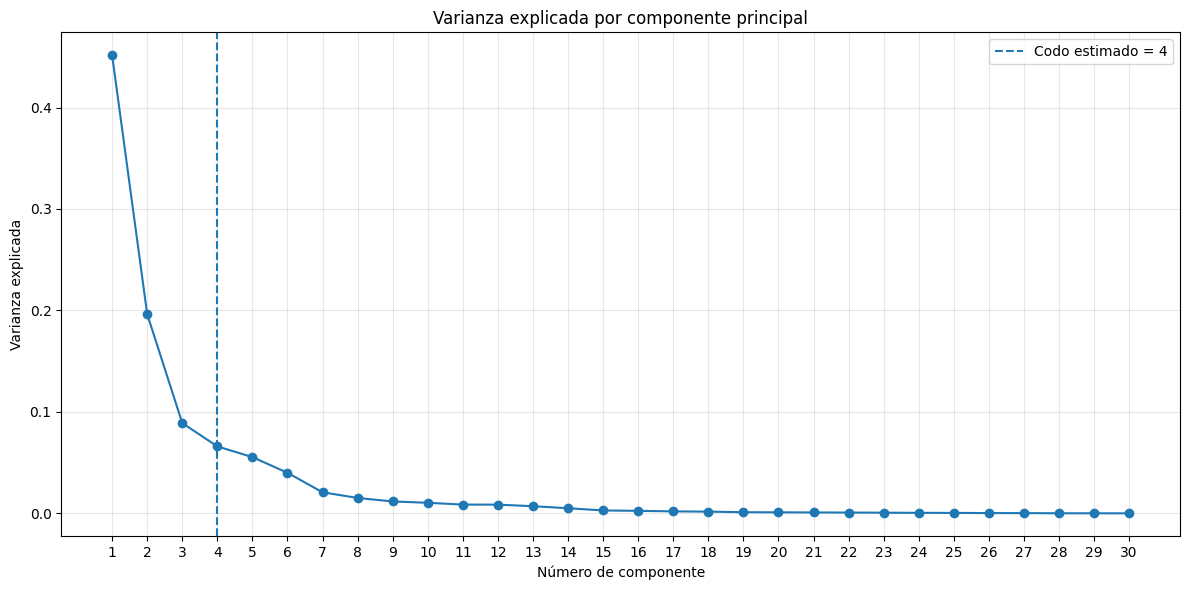


COMPONENTES NECESARIOS POR UMBRAL DE VARIANZA
umbral_varianza  n_componentes  varianza_acumulada_real
            60%              2                 0.647849
            70%              3                 0.736828
            80%              4                 0.802796
            85%              5                 0.858205
            90%              7                 0.918914
            95%             10                 0.956158
            99%             16                 0.990634


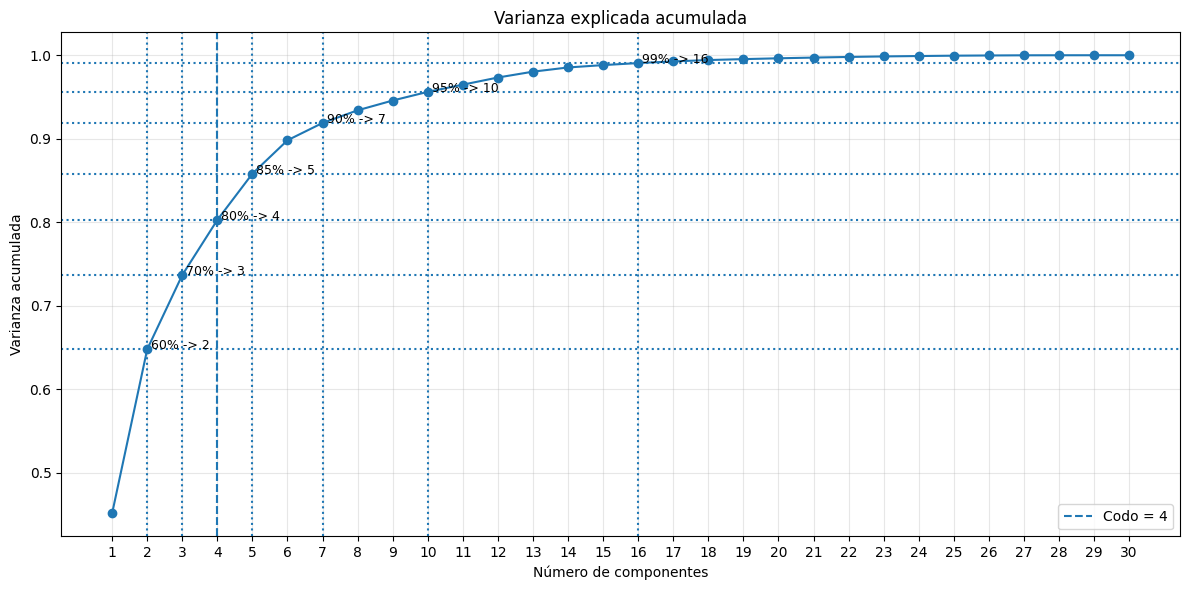


CANTIDADES DE COMPONENTES A PROBAR
[2, 3, 4, 5, 7, 10, 16]

Entrenando modelo con 2 componentes...

Entrenando modelo con 3 componentes...

Entrenando modelo con 4 componentes...

Entrenando modelo con 5 componentes...

Entrenando modelo con 7 componentes...

Entrenando modelo con 10 componentes...

Entrenando modelo con 16 componentes...

COMPARACIÓN DE RESULTADOS
          modelo  n_componentes  varianza_acumulada  accuracy  f1_score      auc
   PCA (2 comp.)              2            0.647849  0.953216  0.962617 0.992114
   PCA (3 comp.)              3            0.736828  0.918129  0.933333 0.988756
   PCA (4 comp.)              4            0.802796  0.959064  0.968037 0.995765
   PCA (5 comp.)              5            0.858205  0.964912  0.971698 0.996787
   PCA (7 comp.)              7            0.918914  0.964912  0.972477 0.995619
  PCA (10 comp.)             10            0.956158  0.976608  0.981481 0.996495
  PCA (16 comp.)             16            0.990634  0.982456  0

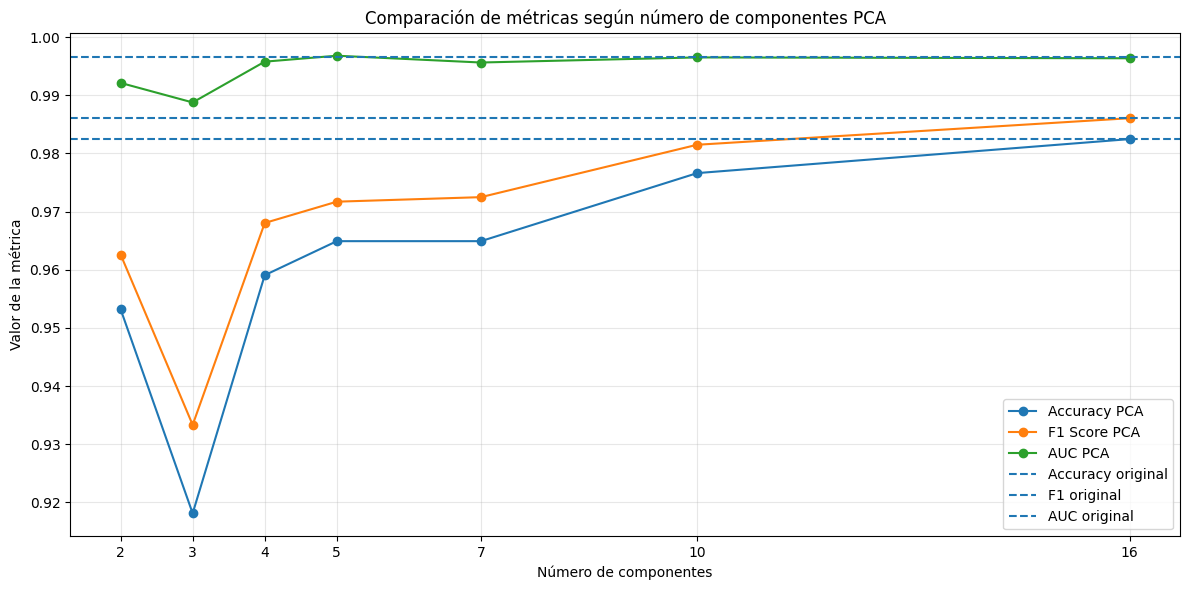


MEJOR DATASET PCA
Mejor número de componentes según F1: 16

Shape X_train_pca_best: (398, 16)
Shape X_test_pca_best : (171, 16)
Shape X_all_pca_best  : (569, 16)
Varianza acumulada del mejor PCA: 0.9906


In [7]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# =========================================================
# 12. PCA COMPLETO PARA ANÁLISIS DE VARIANZA
# =========================================================
print("\n" + "=" * 70)
print("PCA COMPLETO - ANÁLISIS DE VARIANZA")
print("=" * 70)

# PCA completo sobre TRAIN escalado
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)
components = np.arange(1, len(explained_var) + 1)

print(f"\nNúmero máximo de componentes posibles: {len(components)}")

# =========================================================
# 13. ENCONTRAR EL CODO (HEURÍSTICA DE DISTANCIA A LA RECTA)
# =========================================================
# Se calcula el punto con mayor distancia a la recta entre
# el primer y último punto de la curva de varianza explicada.
points = np.column_stack((components, explained_var))

first_point = points[0]
last_point = points[-1]

line_vector = last_point - first_point
line_vector = line_vector / np.linalg.norm(line_vector)

vector_from_first = points - first_point
projection = np.outer(np.dot(vector_from_first, line_vector), line_vector)
distance_to_line = np.linalg.norm(vector_from_first - projection, axis=1)

elbow_idx = np.argmax(distance_to_line)
elbow_component = int(components[elbow_idx])

print(f"\nComponente estimado como codo: {elbow_component}")
print(f"Varianza explicada en el codo: {explained_var[elbow_idx]:.4f}")
print(f"Varianza acumulada hasta el codo: {cum_explained_var[elbow_idx]:.4f}")

# =========================================================
# 14. GRAFICAR VARIANZA EXPLICADA
# =========================================================
plt.figure(figsize=(12, 6))
plt.plot(components, explained_var, marker='o')
plt.axvline(elbow_component, linestyle='--', label=f'Codo estimado = {elbow_component}')
plt.title("Varianza explicada por componente principal")
plt.xlabel("Número de componente")
plt.ylabel("Varianza explicada")
plt.xticks(components)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 15. GRAFICAR VARIANZA EXPLICADA ACUMULADA
# =========================================================
thresholds = [0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99]
threshold_rows = []

for t in thresholds:
    n_comp = int(np.argmax(cum_explained_var >= t) + 1)
    threshold_rows.append({
        "umbral_varianza": f"{int(t*100)}%",
        "n_componentes": n_comp,
        "varianza_acumulada_real": cum_explained_var[n_comp - 1]
    })

threshold_df = pd.DataFrame(threshold_rows)

print("\n" + "=" * 70)
print("COMPONENTES NECESARIOS POR UMBRAL DE VARIANZA")
print("=" * 70)
print(threshold_df.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.plot(components, cum_explained_var, marker='o')
plt.axvline(elbow_component, linestyle='--', label=f'Codo = {elbow_component}')

for row in threshold_rows:
    n_comp = row["n_componentes"]
    var_real = row["varianza_acumulada_real"]
    label_txt = row["umbral_varianza"]

    plt.axhline(var_real, linestyle=':')
    plt.axvline(n_comp, linestyle=':')
    plt.text(n_comp, var_real, f" {label_txt} -> {n_comp}", fontsize=9)

plt.title("Varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.xticks(components)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 16. DATASET PCA COMPLETO PARA VISUALIZACIÓN
#    Esto te sirve si quieres seguir usando heatmaps con TODO el dataset
# =========================================================
pca_full_columns = [f"PC{i+1}" for i in range(X_train_scaled.shape[1])]

X_all_scaled = pd.DataFrame(
    scaler.transform(X),
    columns=X.columns,
    index=X.index
)

X_all_pca_full_df = pd.DataFrame(
    pca_full.transform(X_all_scaled),
    columns=pca_full_columns,
    index=X.index
)

X_train_pca_full_df = pd.DataFrame(
    pca_full.transform(X_train_scaled),
    columns=pca_full_columns,
    index=X_train_scaled.index
)

X_test_pca_full_df = pd.DataFrame(
    pca_full.transform(X_test_scaled),
    columns=pca_full_columns,
    index=X_test_scaled.index
)

# =========================================================
# 17. CREAR MODELOS CON DISTINTAS CANTIDADES DE COMPONENTES
#    Se usan:
#    - el codo
#    - los componentes de 60%, 70%, 80%, 85%, 90%, 95%, 99%
# =========================================================
candidate_components = sorted(set(
    [elbow_component] + threshold_df["n_componentes"].tolist()
))

print("\n" + "=" * 70)
print("CANTIDADES DE COMPONENTES A PROBAR")
print("=" * 70)
print(candidate_components)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_iter = [
    {
        "penalty": ["l1", "l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear"],
        "class_weight": [None, "balanced"]
    },
    {
        "penalty": ["l2"],
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["lbfgs"],
        "class_weight": [None, "balanced"]
    }
]

results_models = []

# Si ya tienes el modelo original sin PCA del bloque anterior,
# se agregan sus métricas para compararlas.
results_models.append({
    "modelo": "Original sin PCA",
    "n_componentes": X_train_scaled.shape[1],
    "varianza_acumulada": 1.0,
    "accuracy": acc,
    "f1_score": f1,
    "auc": auc,
    "mejores_parametros": "N/A"
})

for n_comp in candidate_components:
    print(f"\nEntrenando modelo con {n_comp} componentes...")

    pca_iter = PCA(n_components=n_comp)
    X_train_pca_iter = pca_iter.fit_transform(X_train_scaled)
    X_test_pca_iter = pca_iter.transform(X_test_scaled)

    grid_search_iter = GridSearchCV(
        estimator=LogisticRegression(max_iter=10000),
        param_grid=param_grid_iter,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

    grid_search_iter.fit(X_train_pca_iter, y_train)

    best_model_iter = grid_search_iter.best_estimator_

    y_pred_iter = best_model_iter.predict(X_test_pca_iter)
    y_prob_iter = best_model_iter.predict_proba(X_test_pca_iter)[:, 1]

    acc_iter = accuracy_score(y_test, y_pred_iter)
    f1_iter = f1_score(y_test, y_pred_iter)
    auc_iter = roc_auc_score(y_test, y_prob_iter)

    results_models.append({
        "modelo": f"PCA ({n_comp} comp.)",
        "n_componentes": n_comp,
        "varianza_acumulada": pca_iter.explained_variance_ratio_.sum(),
        "accuracy": acc_iter,
        "f1_score": f1_iter,
        "auc": auc_iter,
        "mejores_parametros": str(grid_search_iter.best_params_)
    })

results_df = pd.DataFrame(results_models)

# Ordenar para visualización
results_df_sorted_by_comp = results_df.sort_values(by="n_componentes").reset_index(drop=True)
results_df_sorted_by_f1 = results_df.sort_values(by="f1_score", ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("COMPARACIÓN DE RESULTADOS")
print("=" * 70)
print(results_df_sorted_by_comp[["modelo", "n_componentes", "varianza_acumulada", "accuracy", "f1_score", "auc"]].to_string(index=False))

print("\n" + "=" * 70)
print("MEJOR MODELO SEGÚN F1 SCORE")
print("=" * 70)
print(results_df_sorted_by_f1.iloc[0].to_string())

# =========================================================
# 18. GRAFICAR COMPARACIÓN DE MÉTRICAS
# =========================================================
results_only_pca = results_df[results_df["modelo"] != "Original sin PCA"].sort_values(by="n_componentes")

plt.figure(figsize=(12, 6))
plt.plot(results_only_pca["n_componentes"], results_only_pca["accuracy"], marker='o', label="Accuracy PCA")
plt.plot(results_only_pca["n_componentes"], results_only_pca["f1_score"], marker='o', label="F1 Score PCA")
plt.plot(results_only_pca["n_componentes"], results_only_pca["auc"], marker='o', label="AUC PCA")

plt.axhline(acc, linestyle='--', label="Accuracy original")
plt.axhline(f1, linestyle='--', label="F1 original")
plt.axhline(auc, linestyle='--', label="AUC original")

plt.title("Comparación de métricas según número de componentes PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Valor de la métrica")
plt.xticks(results_only_pca["n_componentes"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 19. CREAR EL NUEVO DATASET FINAL CON EL MEJOR NÚMERO DE COMPONENTES
# =========================================================
best_pca_row = results_df_sorted_by_f1[results_df_sorted_by_f1["modelo"] != "Original sin PCA"].iloc[0]
best_n_components = int(best_pca_row["n_componentes"])

print("\n" + "=" * 70)
print("MEJOR DATASET PCA")
print("=" * 70)
print(f"Mejor número de componentes según F1: {best_n_components}")

pca_best = PCA(n_components=best_n_components)

X_train_pca_best = pd.DataFrame(
    pca_best.fit_transform(X_train_scaled),
    columns=[f"PC{i+1}" for i in range(best_n_components)],
    index=X_train_scaled.index
)

X_test_pca_best = pd.DataFrame(
    pca_best.transform(X_test_scaled),
    columns=[f"PC{i+1}" for i in range(best_n_components)],
    index=X_test_scaled.index
)

X_all_pca_best = pd.DataFrame(
    pca_best.transform(X_all_scaled),
    columns=[f"PC{i+1}" for i in range(best_n_components)],
    index=X.index
)

print(f"\nShape X_train_pca_best: {X_train_pca_best.shape}")
print(f"Shape X_test_pca_best : {X_test_pca_best.shape}")
print(f"Shape X_all_pca_best  : {X_all_pca_best.shape}")
print(f"Varianza acumulada del mejor PCA: {pca_best.explained_variance_ratio_.sum():.4f}")


GRÁFICAS DE CLASIFICACIÓN UNIVARIABLE


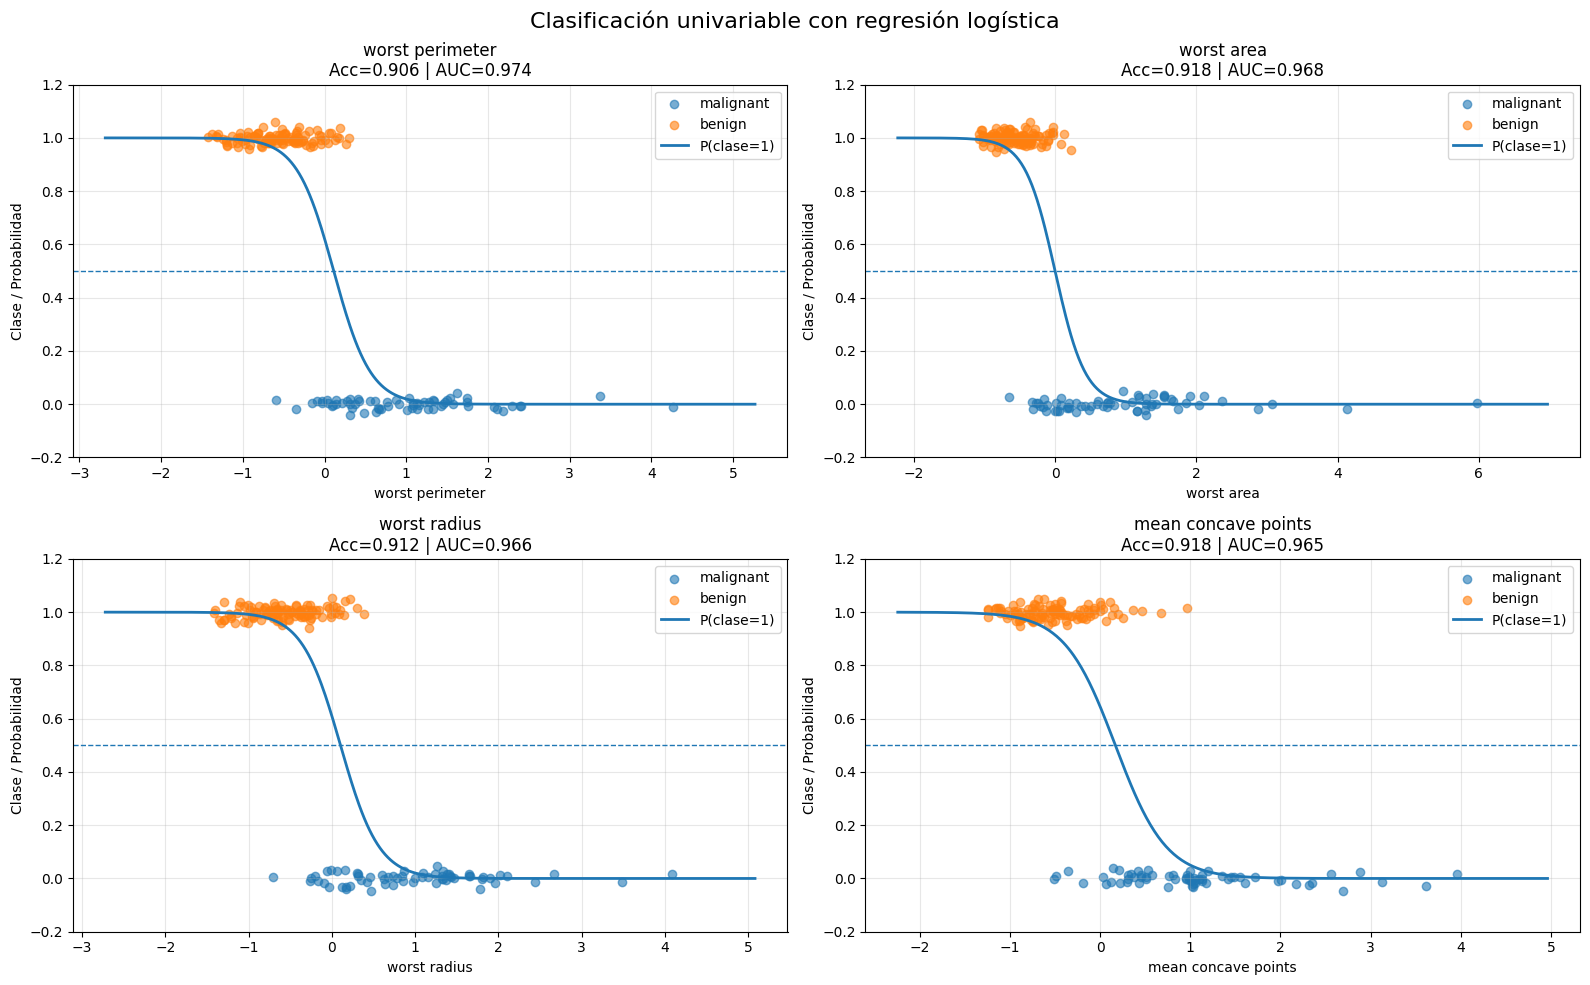


GRÁFICAS DE CLASIFICACIÓN BIVARIABLE


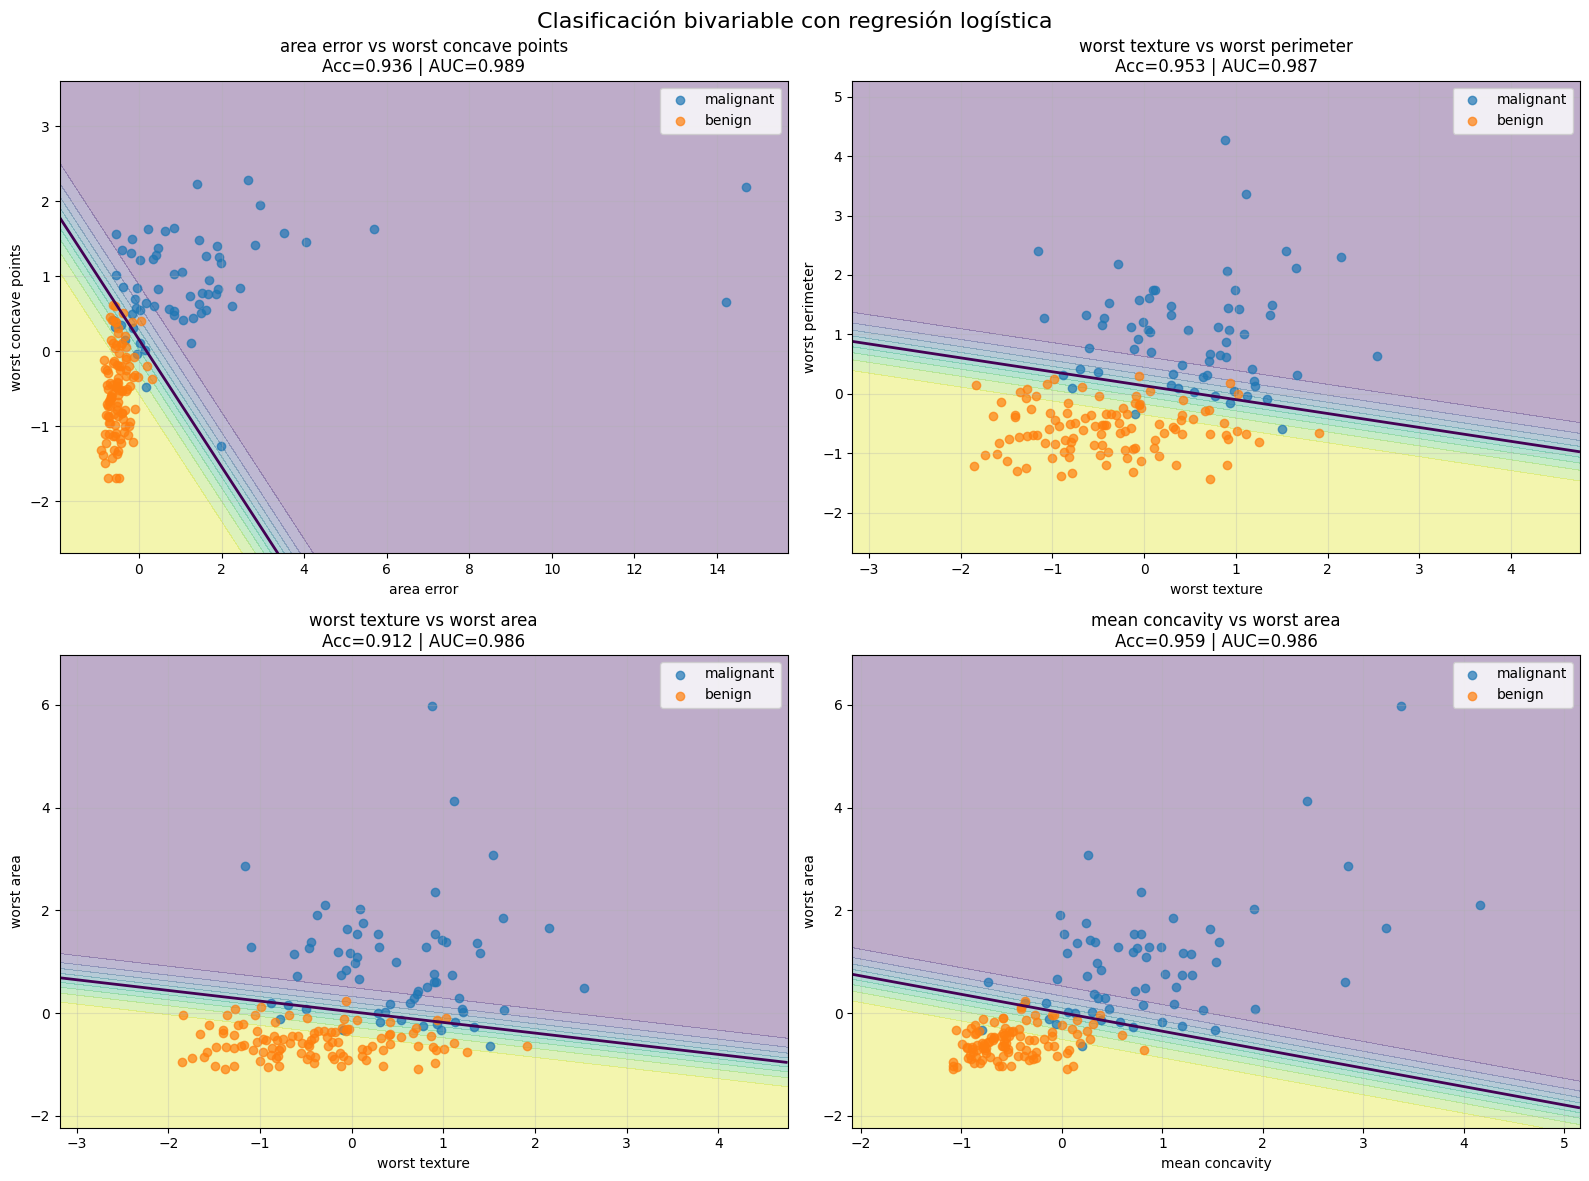


LOADINGS DEL MEJOR PCA

Matriz de loadings:
                            PC1     PC2     PC3     PC4     PC5     PC6  \
mean radius              0.7990 -0.5643  0.0018 -0.0650 -0.0434  0.0097   
mean texture             0.3541 -0.1768  0.2814  0.8184 -0.0079  0.0125   
mean perimeter           0.8304 -0.5185 -0.0025 -0.0650 -0.0429  0.0088   
mean area                0.8094 -0.5504  0.0375 -0.0777 -0.0072 -0.0214   
mean smoothness          0.5136  0.4433 -0.2930 -0.0931  0.4553 -0.3240   
mean compactness         0.8815  0.3534 -0.1270 -0.0113 -0.0285  0.0010   
mean concavity           0.9347  0.1772 -0.0133 -0.0254 -0.1192 -0.0359   
mean concave points      0.9548 -0.0790 -0.0767 -0.0776  0.0558 -0.0736   
mean symmetry            0.5130  0.4750 -0.0996 -0.0724  0.3845  0.3804   
mean fractal dimension   0.2493  0.8779 -0.0570 -0.0299  0.0278 -0.1131   
radius error             0.7811 -0.2260  0.3914 -0.1767  0.2322 -0.0249   
texture error            0.0234  0.2325  0.7034  0.4317

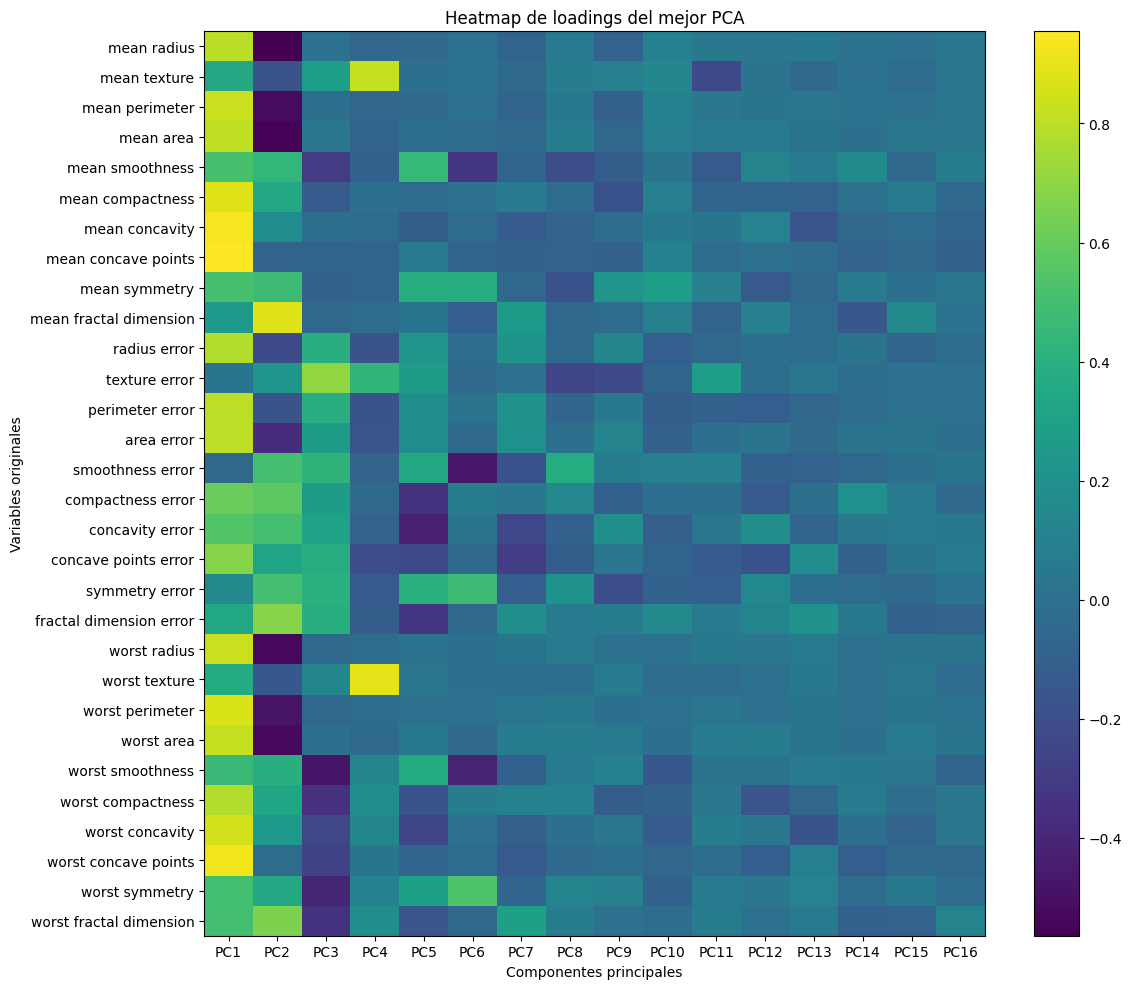


MAYOR APORTE A LOS COMPONENTES RELEVANTES

Variables con mayor aporte por componente:
componente  ranking                variable  contribucion_pct  loading
       PC1        1     mean concave points            6.7126   0.9548
       PC1        2          mean concavity            6.4336   0.9347
       PC1        3    worst concave points            6.2528   0.9215
       PC1        4        mean compactness            5.7218   0.8815
       PC1        5         worst perimeter            5.5267   0.8664
       PC2        1  mean fractal dimension           13.0539   0.8779
       PC2        2 fractal dimension error            7.8069   0.6789
       PC2        3 worst fractal dimension            7.2329   0.6534
       PC2        4       compactness error            5.5490   0.5723
       PC2        5             mean radius            5.3939  -0.5643
       PC3        1           texture error           18.4862   0.7034
       PC3        2        worst smoothness            8.5671

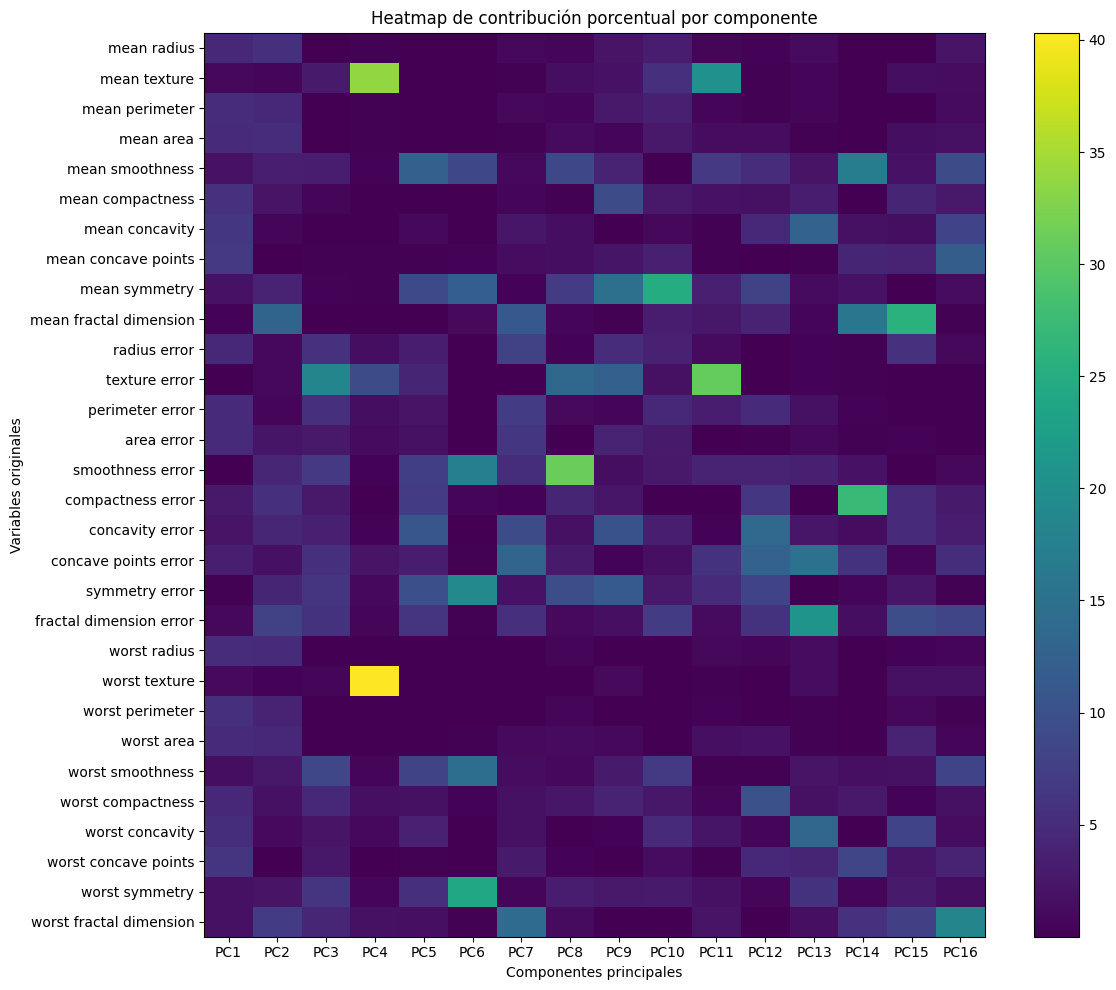


RESUMEN DE INTERPRETACIÓN DE COMPONENTES
PC1: mayor aporte de mean concave points (6.71%), mean concavity (6.43%), worst concave points (6.25%)
PC2: mayor aporte de mean fractal dimension (13.05%), fractal dimension error (7.81%), worst fractal dimension (7.23%)
PC3: mayor aporte de texture error (18.49%), worst smoothness (8.57%), smoothness error (6.66%)
PC4: mayor aporte de worst texture (40.32%), mean texture (33.76%), texture error (9.39%)
PC5: mayor aporte de mean smoothness (12.44%), concavity error (10.82%), symmetry error (9.87%)
PC6: mayor aporte de worst symmetry (24.14%), symmetry error (18.98%), smoothness error (17.44%)
PC7: mayor aporte de worst fractal dimension (14.15%), concave points error (13.20%), mean fractal dimension (11.12%)
PC8: mayor aporte de smoothness error (31.06%), texture error (13.50%), symmetry error (9.52%)
PC9: mayor aporte de mean symmetry (14.93%), texture error (12.37%), symmetry error (11.35%)
PC10: mayor aporte de mean symmetry (24.95%), fract

In [8]:
# =========================================================
# 20. GRÁFICAS DE CLASIFICACIÓN UNIVARIABLE
#    Se grafican las mejores 4 variables univariables
# =========================================================
print("\n" + "=" * 70)
print("GRÁFICAS DE CLASIFICACIÓN UNIVARIABLE")
print("=" * 70)

rng = np.random.default_rng(42)
top_uni_plot_features = univ_df.head(4)["feature"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, top_uni_plot_features):
    model_uni = LogisticRegression(max_iter=10000)
    model_uni.fit(X_train_scaled[[feature]], y_train)

    # Curva de probabilidad
    x_min = min(X_train_scaled[feature].min(), X_test_scaled[feature].min()) - 1
    x_max = max(X_train_scaled[feature].max(), X_test_scaled[feature].max()) + 1
    x_grid = np.linspace(x_min, x_max, 500).reshape(-1, 1)
    x_grid_df = pd.DataFrame(x_grid, columns=[feature])

    y_prob_grid = model_uni.predict_proba(x_grid_df)[:, 1]

    # Datos de test para visualizar clasificación
    idx0 = y_test[y_test == 0].index
    idx1 = y_test[y_test == 1].index

    jitter0 = rng.normal(0, 0.02, len(idx0))
    jitter1 = rng.normal(0, 0.02, len(idx1))

    ax.scatter(
        X_test_scaled.loc[idx0, feature],
        np.zeros(len(idx0)) + jitter0,
        alpha=0.6,
        label=data.target_names[0]
    )
    ax.scatter(
        X_test_scaled.loc[idx1, feature],
        np.ones(len(idx1)) + jitter1,
        alpha=0.6,
        label=data.target_names[1]
    )

    ax.plot(x_grid, y_prob_grid, linewidth=2, label="P(clase=1)")
    ax.axhline(0.5, linestyle="--", linewidth=1)

    auc_uni = univ_df.loc[univ_df["feature"] == feature, "auc_test"].values[0]
    acc_uni = univ_df.loc[univ_df["feature"] == feature, "accuracy_test"].values[0]

    ax.set_title(f"{feature}\nAcc={acc_uni:.3f} | AUC={auc_uni:.3f}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Clase / Probabilidad")
    ax.set_ylim(-0.2, 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Clasificación univariable con regresión logística", fontsize=16)
plt.tight_layout()
plt.show()


# =========================================================
# 21. GRÁFICAS DE CLASIFICACIÓN BIVARIABLE
#    Se grafican los mejores 4 pares bivariable
# =========================================================
print("\n" + "=" * 70)
print("GRÁFICAS DE CLASIFICACIÓN BIVARIABLE")
print("=" * 70)

top_bi_plot_pairs = biv_df.head(4)[["feature_1", "feature_2"]].values.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (f1, f2) in zip(axes, top_bi_plot_pairs):
    model_bi = LogisticRegression(max_iter=10000)
    model_bi.fit(X_train_scaled[[f1, f2]], y_train)

    # Malla para frontera de decisión
    x_min = min(X_train_scaled[f1].min(), X_test_scaled[f1].min()) - 1
    x_max = max(X_train_scaled[f1].max(), X_test_scaled[f1].max()) + 1
    y_min = min(X_train_scaled[f2].min(), X_test_scaled[f2].min()) - 1
    y_max = max(X_train_scaled[f2].max(), X_test_scaled[f2].max()) + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid_df = pd.DataFrame(
        np.c_[xx.ravel(), yy.ravel()],
        columns=[f1, f2]
    )

    zz = model_bi.predict_proba(grid_df)[:, 1].reshape(xx.shape)

    # Región de clasificación y frontera
    contour = ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 11), alpha=0.35)
    ax.contour(xx, yy, zz, levels=[0.5], linewidths=2)

    idx0 = y_test[y_test == 0].index
    idx1 = y_test[y_test == 1].index

    ax.scatter(
        X_test_scaled.loc[idx0, f1],
        X_test_scaled.loc[idx0, f2],
        alpha=0.7,
        label=data.target_names[0]
    )
    ax.scatter(
        X_test_scaled.loc[idx1, f1],
        X_test_scaled.loc[idx1, f2],
        alpha=0.7,
        label=data.target_names[1]
    )

    row_pair = biv_df[(biv_df["feature_1"] == f1) & (biv_df["feature_2"] == f2)].iloc[0]

    ax.set_title(
        f"{f1} vs {f2}\nAcc={row_pair['accuracy_test']:.3f} | AUC={row_pair['auc_test']:.3f}"
    )
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Clasificación bivariable con regresión logística", fontsize=16)
plt.tight_layout()
plt.show()


# =========================================================
# 22. OBTENER LOADINGS DEL MEJOR PCA
#    Loadings = components_.T * sqrt(explained_variance_)
# =========================================================
print("\n" + "=" * 70)
print("LOADINGS DEL MEJOR PCA")
print("=" * 70)

pc_names_best = [f"PC{i+1}" for i in range(best_n_components)]

loadings_df = pd.DataFrame(
    pca_best.components_.T * np.sqrt(pca_best.explained_variance_),
    index=X.columns,
    columns=pc_names_best
)

print("\nMatriz de loadings:")
print(loadings_df.round(4))


# =========================================================
# 23. HEATMAP DE LOADINGS
# =========================================================
plt.figure(figsize=(12, 10))
im = plt.imshow(loadings_df.values, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(loadings_df.columns)), loadings_df.columns)
plt.yticks(range(len(loadings_df.index)), loadings_df.index)
plt.title("Heatmap de loadings del mejor PCA")
plt.xlabel("Componentes principales")
plt.ylabel("Variables originales")
plt.tight_layout()
plt.show()


# =========================================================
# 24. REVISAR MAYOR APORTE A LOS COMPONENTES RELEVANTES
#    Se usa contribución porcentual basada en loadings^2
# =========================================================
print("\n" + "=" * 70)
print("MAYOR APORTE A LOS COMPONENTES RELEVANTES")
print("=" * 70)

contrib_pct_df = (loadings_df ** 2)
contrib_pct_df = contrib_pct_df.div(contrib_pct_df.sum(axis=0), axis=1) * 100

top_contrib_rows = []

for pc in contrib_pct_df.columns:
    top_vars = contrib_pct_df[pc].sort_values(ascending=False).head(5)

    for rank, (variable, contribution) in enumerate(top_vars.items(), start=1):
        top_contrib_rows.append({
            "componente": pc,
            "ranking": rank,
            "variable": variable,
            "contribucion_pct": contribution,
            "loading": loadings_df.loc[variable, pc]
        })

top_contrib_df = pd.DataFrame(top_contrib_rows)

print("\nVariables con mayor aporte por componente:")
print(top_contrib_df.round(4).to_string(index=False))


# =========================================================
# 25. HEATMAP DE CONTRIBUCIÓN PORCENTUAL
# =========================================================
plt.figure(figsize=(12, 10))
im = plt.imshow(contrib_pct_df.values, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(contrib_pct_df.columns)), contrib_pct_df.columns)
plt.yticks(range(len(contrib_pct_df.index)), contrib_pct_df.index)
plt.title("Heatmap de contribución porcentual por componente")
plt.xlabel("Componentes principales")
plt.ylabel("Variables originales")
plt.tight_layout()
plt.show()


# =========================================================
# 26. RESUMEN INTERPRETABLE DE LOS COMPONENTES RELEVANTES
# =========================================================
print("\n" + "=" * 70)
print("RESUMEN DE INTERPRETACIÓN DE COMPONENTES")
print("=" * 70)

for pc in contrib_pct_df.columns:
    top3 = contrib_pct_df[pc].sort_values(ascending=False).head(3)
    texto = ", ".join([f"{var} ({val:.2f}%)" for var, val in top3.items()])
    print(f"{pc}: mayor aporte de {texto}")